# 🫁 Phase 1.1: Image-Only Classifier (Balanced & Scaled Cohort)

This notebook trains a deep CNN visual backbone (**PneumoFusionNet**) to perform binary pneumonia classification from chest X-ray images. 

### Key features of this notebook:
- **Strict Patient-Level Split**: No patient overlap between Train, Validation, and Test sets to prevent data leakage.
- **PA Viewpoint Only**: Filters dataset for Posterior-Anterior (PA) projections.
- **Balanced Sampling**: Constructs a balanced cohort of 354 images (177 Normal / 177 Pneumonia).
- **Feature Extraction**: Saves 1024-d visual embeddings for downstream multimodal fusion.

In [1]:
# --- CELL 0: Imports & Reproducibility ---
import os, random, copy, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score, auc
)

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    print('Memory:', torch.cuda.get_device_properties(DEVICE).total_memory / 1e9, 'GB')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Memory: 4.294508544 GB


In [2]:
# --- CELL 1: Paths & Hyperparameters ---
BASE_DIR   = r'C:\2026\PneumoFusionNet\mimic\1000_dataset'
CSV_PATH   = os.path.join(BASE_DIR, 'mimic_paired_dataset.csv')
SAVE_DIR   = os.path.join(BASE_DIR, 'outputs', 'Phase_1.1_PA_balanced_scaled')
MODEL_PATH = os.path.join(SAVE_DIR, 'best_pneumofusion_mimic.pth')

IMG_SIZE      = 224
BATCH_SIZE    = 8
NUM_EPOCHS    = 40
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
NUM_CLASSES   = 2
WARMUP_EPOCHS = 3
GRAD_CLIP     = 1.0

CLASSES = ['NORMAL', 'PNEUMONIA']

os.makedirs(SAVE_DIR, exist_ok=True)
print('CSV path :', CSV_PATH)
print('Exists   :', os.path.exists(CSV_PATH))
print('Save dir :', SAVE_DIR)

CSV path : C:\2026\PneumoFusionNet\mimic\1000_dataset\mimic_paired_dataset.csv
Exists   : True
Save dir : C:\2026\PneumoFusionNet\mimic\1000_dataset\outputs\Phase_1.1_PA_balanced_scaled


In [3]:
# --- CELL 2: Data Preprocessing ---
df = pd.read_csv(CSV_PATH)

def resolve_data_path(path):
    if pd.isna(path) or str(path).strip() == '':
        return ''
    path = str(path).replace('/', os.sep).replace('\\', os.sep)
    return path if os.path.isabs(path) else os.path.join(BASE_DIR, path)

df['image_path'] = df['image_path'].apply(resolve_data_path)

# Map pneumonia label -> 1, normal (no finding) -> 0
df['label'] = np.select(
    [df['pneumonia_label'].eq(1.0), df['no_finding_label'].eq(1.0)],
    [1, 0],
    default=-1
)

# Filter for PA viewpoint and non-negative labels
df = df[(df['label'] >= 0) & df['view_position'].eq('PA')].copy()
df['label_name'] = df['label'].map({0: 'Normal', 1: 'Pneumonia'})

# Balanced sampling based on minority class (Pneumonia)
class_counts = df['label'].value_counts()
n_per_class  = int(class_counts.min())
print(f'Balancing dataset: choosing {n_per_class} normal + {n_per_class} pneumonia samples...')

normal_df    = df[df['label'] == 0].sample(n=n_per_class, random_state=SEED).reset_index(drop=True)
pneumonia_df = df[df['label'] == 1].sample(n=n_per_class, random_state=SEED).reset_index(drop=True)
df = pd.concat([normal_df, pneumonia_df]).sample(frac=1, random_state=SEED).reset_index(drop=True)

# Verify image existence
missing = df['image_path'].apply(lambda p: not os.path.exists(p)).sum()
print('Total samples :', df.shape[0])
print('Images found  :', len(df) - missing, '/', len(df))
if missing > 0:
    print('WARNING: Missing', missing, 'images!')
else:
    print('All images verified successfully!')

Balancing dataset: choosing 427 normal + 427 pneumonia samples...
Total samples : 854
Images found  : 854 / 854
All images verified successfully!


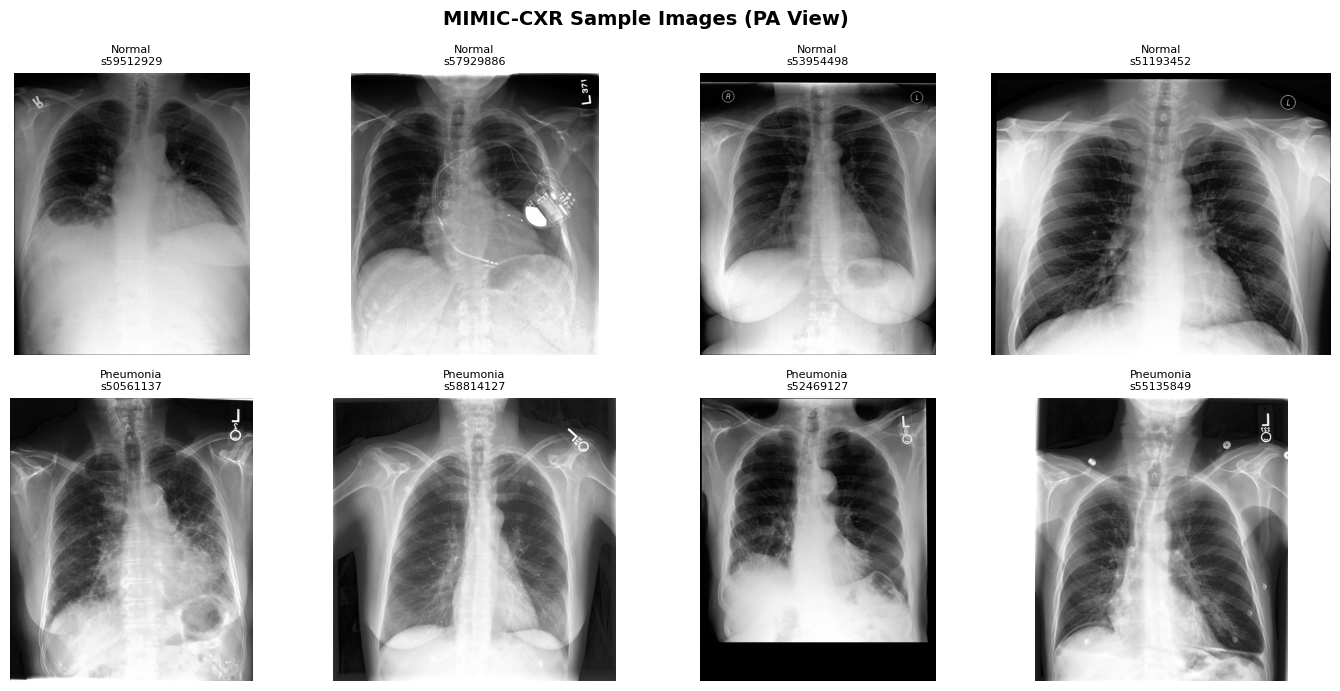

In [4]:
# --- CELL 3: Plot Sample Images ---
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('MIMIC-CXR Sample Images (PA View)', fontsize=14, fontweight='bold')
for row, lname in enumerate(['Normal', 'Pneumonia']):
    subset = df[df.label_name == lname].head(4)
    for col, (_, rec) in enumerate(subset.iterrows()):
        ax = axes[row][col]
        try:
            img = Image.open(rec.image_path).convert('L')
            ax.imshow(img, cmap='gray')
        except Exception as e:
            ax.text(0.5, 0.5, str(e)[:30], ha='center', transform=ax.transAxes, fontsize=7)
        ax.set_title(f'{lname}\ns{rec.study_id}', fontsize=8)
        ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'sample_images.png'), dpi=120, bbox_inches='tight')
plt.show()

In [5]:
# --- CELL 4: Patient-Level Split ---
# 70% Train, 30% Temp
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=14)
train_idx, temp_idx = next(gss.split(df, groups=df['subject_id']))
train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df = df.iloc[temp_idx].reset_index(drop=True)

# 50% Val, 50% Test of temp (corresponds to 15% / 15% overall split)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=4)
val_idx, test_idx = next(gss_val.split(temp_df, groups=temp_df['subject_id']))
val_df   = temp_df.iloc[val_idx].reset_index(drop=True)
test_df  = temp_df.iloc[test_idx].reset_index(drop=True)

print('=' * 60)
print('DATASET SPLIT SUMMARY')
print('=' * 60)
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    n_total    = len(split_df)
    n_pneumonia = split_df['label'].sum()
    n_normal   = (split_df['label'] == 0).sum()
    print(f'{split_name:6s} | Total: {n_total:3d} | Normal: {n_normal:3d} | Pneumonia: {n_pneumonia:3d}')
print('=' * 60)

DATASET SPLIT SUMMARY
Train  | Total: 590 | Normal: 318 | Pneumonia: 272
Val    | Total: 130 | Normal:  50 | Pneumonia:  80
Test   | Total: 134 | Normal:  59 | Pneumonia:  75


In [6]:
# --- CELL 5: Normalization Stats ---
print('Computing normalization stats from training set...')
means = []
stds  = []

for idx in range(min(len(train_df), 200)):
    try:
        img = Image.open(train_df.iloc[idx]['image_path']).convert('L')
        img_array = np.array(img, dtype=np.float32) / 255.0
        means.append(img_array.mean())
        stds.append(img_array.std())
    except:
        continue

MEAN = [np.mean(means)]
STD  = [np.mean(stds)]
print(f'Computed MEAN: {MEAN[0]:.4f}')
print(f'Computed STD : {STD[0]:.4f}')

Computing normalization stats from training set...
Computed MEAN: 0.4818
Computed STD : 0.2996


In [7]:
# --- CELL 6: Transforms ---
tfms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((256, 256)),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
    'val': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
    'test': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
}
print('Transforms loaded successfully.')

Transforms loaded successfully.


In [8]:
# --- CELL 7: Dataset & Dataloaders ---
class MIMICDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row.image_path)
        if self.transform:
            img = self.transform(img)
        label = int(row.label)
        return img, label

train_labels  = train_df['label'].values
class_counts  = np.bincount(train_labels)
sample_weights = [1.0 / class_counts[l] for l in train_labels]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

dataloaders = {
    'train': DataLoader(
        MIMICDataset(train_df, tfms['train']),
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=0
    ),
    'val': DataLoader(
        MIMICDataset(val_df, tfms['val']),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    ),
    'test': DataLoader(
        MIMICDataset(test_df, tfms['test']),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    ),
}

dataset_sizes = {'train': len(train_df), 'val': len(val_df), 'test': len(test_df)}
print(f'Dataset sizes: {dataset_sizes}')

Dataset sizes: {'train': 590, 'val': 130, 'test': 134}


In [9]:
# --- CELL 8: Verify Sampler ---
batch_labels = []
for _, lbls in dataloaders['train']:
    batch_labels.extend(lbls.tolist())
    if len(batch_labels) >= 500:
        break
print('Sampled label distribution from train loader (500 samples):', Counter(batch_labels))

Sampled label distribution from train loader (500 samples): Counter({0: 267, 1: 237})


In [10]:
# --- CELL 9: Model Architecture ---
class GCSA(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels)
        )
        self.sigmoid      = nn.Sigmoid()
        self.conv_spatial = nn.Conv2d(2, 1, kernel_size=7, padding=3)

    def forward(self, x):
        B, C, H, W = x.shape
        avg    = self.avg_pool(x).view(B, C)
        mx     = self.max_pool(x).view(B, C)
        ch_att = self.sigmoid(self.mlp(avg) + self.mlp(mx)).view(B, C, 1, 1)
        x      = x * ch_att
        sp     = torch.cat([x.mean(1, keepdim=True), x.max(1, keepdim=True)[0]], dim=1)
        sp_att = self.sigmoid(self.conv_spatial(sp))
        return x * sp_att

class DSC(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, 3, padding=1, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        return F.relu(self.bn(self.pw(self.dw(x))), inplace=True)

class PneumoFusionNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, freeze_until=7):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        original_conv1 = resnet.conv1
        resnet.conv1   = nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            resnet.conv1.weight = nn.Parameter(
                original_conv1.weight.mean(dim=1, keepdim=True)
            )

        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        for i, child in enumerate(self.backbone.children()):
            if i < freeze_until:
                for p in child.parameters():
                    p.requires_grad = False

        self.dsc        = DSC(2048, 1024)
        self.gcsa       = GCSA(1024)
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.dsc(x)
        x = self.gcsa(x)
        x = self.pool(x).flatten(1)
        return self.classifier(x)

    def get_features(self, x):
        x = self.backbone(x)
        x = self.dsc(x)
        x = self.gcsa(x)
        return self.pool(x).flatten(1)

model = PneumoFusionNet().to(DEVICE)
print('PneumoFusionNet architecture compiled successfully.')

PneumoFusionNet architecture compiled successfully.


In [11]:
# --- CELL 10: Loss, Optimizer & Scheduler ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

linear_warmup = LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine_anneal = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS)
scheduler     = SequentialLR(
    optimizer,
    schedulers=[linear_warmup, cosine_anneal],
    milestones=[WARMUP_EPOCHS]
)
print('Optimizer, Loss, Scheduler configured.')

Optimizer, Loss, Scheduler configured.


In [12]:
# --- CELL 11: Training Loop ---
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)
            total_loss  += loss.item() * len(labels)
            probs        = F.softmax(outputs, dim=1)[:, 1]
            all_preds.extend(outputs.argmax(1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    auc_score = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0

    return avg_loss, accuracy, auc_score, all_preds, all_labels, all_probs

history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}

best_val_auc     = 0.0
best_epoch       = 0
patience         = 10
patience_counter = 0

print('\n' + '='*80)
print('TRAINING STARTED')
print('='*80)

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss    = 0.0
    train_correct = 0
    train_n       = 0

    for imgs, labels in dataloaders['train']:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()
        train_loss    += loss.item() * len(labels)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_n       += len(labels)

    scheduler.step()

    train_loss_avg = train_loss / train_n
    train_acc      = train_correct / train_n

    val_loss, val_acc, val_auc, _, _, _ = evaluate(
        model, dataloaders['val'], criterion, DEVICE
    )

    history['train_loss'].append(train_loss_avg)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc     = val_auc
        best_epoch       = epoch
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_PATH)
        best_marker = ' <- BEST'
    else:
        best_marker = ''
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0 or best_marker != '':
        print(f'Epoch [{epoch+1:2d}/{NUM_EPOCHS}] | '
              f'Train Loss: {train_loss_avg:.4f} ({train_acc:.3f}) | '
              f'Val Loss: {val_loss:.4f} ({val_acc:.3f}) | '
              f'Val AUC: {val_auc:.4f}{best_marker}')

    if patience_counter >= patience:
        print(f'\nEarly stopping at epoch {epoch+1} (no improvement for {patience} epochs)')
        break
print('='*80)


TRAINING STARTED
Epoch [ 1/40] | Train Loss: 0.6922 (0.531) | Val Loss: 0.6911 (0.538) | Val AUC: 0.6565 <- BEST
Epoch [ 2/40] | Train Loss: 0.6559 (0.661) | Val Loss: 0.7787 (0.546) | Val AUC: 0.6970 <- BEST
Epoch [ 3/40] | Train Loss: 0.5845 (0.695) | Val Loss: 0.8626 (0.638) | Val AUC: 0.7263 <- BEST
Epoch [ 5/40] | Train Loss: 0.5511 (0.712) | Val Loss: 1.0666 (0.669) | Val AUC: 0.7050
Epoch [10/40] | Train Loss: 0.4565 (0.808) | Val Loss: 1.0141 (0.608) | Val AUC: 0.7137
Epoch [11/40] | Train Loss: 0.4500 (0.810) | Val Loss: 0.8174 (0.692) | Val AUC: 0.7508 <- BEST
Epoch [13/40] | Train Loss: 0.4137 (0.827) | Val Loss: 0.8719 (0.654) | Val AUC: 0.7568 <- BEST
Epoch [14/40] | Train Loss: 0.3704 (0.836) | Val Loss: 0.9241 (0.677) | Val AUC: 0.7590 <- BEST
Epoch [15/40] | Train Loss: 0.3848 (0.841) | Val Loss: 1.0825 (0.638) | Val AUC: 0.7180
Epoch [20/40] | Train Loss: 0.3349 (0.881) | Val Loss: 1.6998 (0.608) | Val AUC: 0.7000

Early stopping at epoch 24 (no improvement for 10 epo

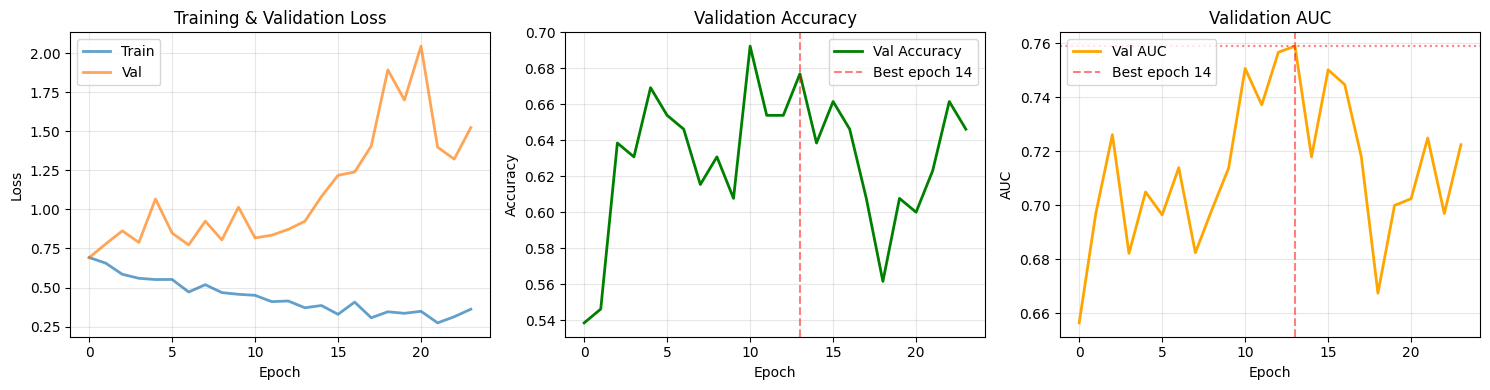

In [13]:
# --- CELL 12: Plot Training Curves ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['train_loss'], label='Train', lw=2, alpha=0.7)
axes[0].plot(history['val_loss'],   label='Val',   lw=2, alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['val_acc'], label='Val Accuracy', lw=2, color='green')
axes[1].axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best epoch {best_epoch+1}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history['val_auc'], label='Val AUC', lw=2, color='orange')
axes[2].axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best epoch {best_epoch+1}')
axes[2].axhline(best_val_auc, color='red', linestyle=':', alpha=0.5)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].set_title('Validation AUC')
axes[2].legend()
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_history.png'), dpi=120, bbox_inches='tight')
plt.show()

In [14]:
# --- CELL 13: Evaluate on Test Set ---
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

test_loss, test_acc, test_auc, test_preds, test_labels, test_probs = evaluate(
    model, dataloaders['test'], criterion, DEVICE
)

print('\n' + '='*60)
print('TEST SET RESULTS')
print('='*60)
print(f'Loss     : {test_loss:.4f}')
print(f'Accuracy : {test_acc:.4f}')
print(f'AUC      : {test_auc:.4f}')
print('\nClassification Report:')
print(classification_report(test_labels, test_preds, target_names=CLASSES))
print('='*60)


TEST SET RESULTS
Loss     : 0.6532
Accuracy : 0.6940
AUC      : 0.8348

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.63      0.75      0.68        59
   PNEUMONIA       0.77      0.65      0.71        75

    accuracy                           0.69       134
   macro avg       0.70      0.70      0.69       134
weighted avg       0.71      0.69      0.69       134



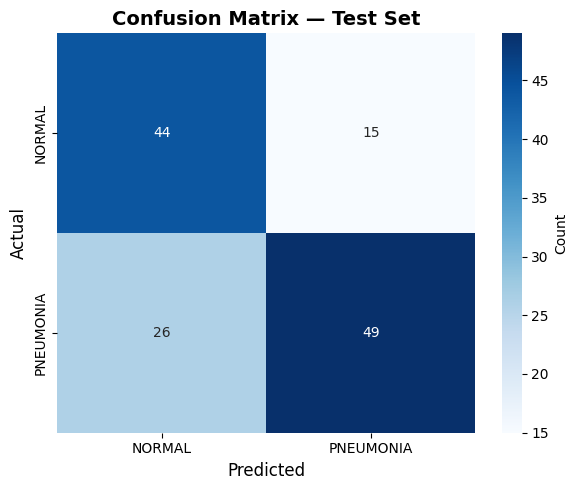

In [15]:
# --- CELL 14: Confusion Matrix ---
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=120, bbox_inches='tight')
plt.show()

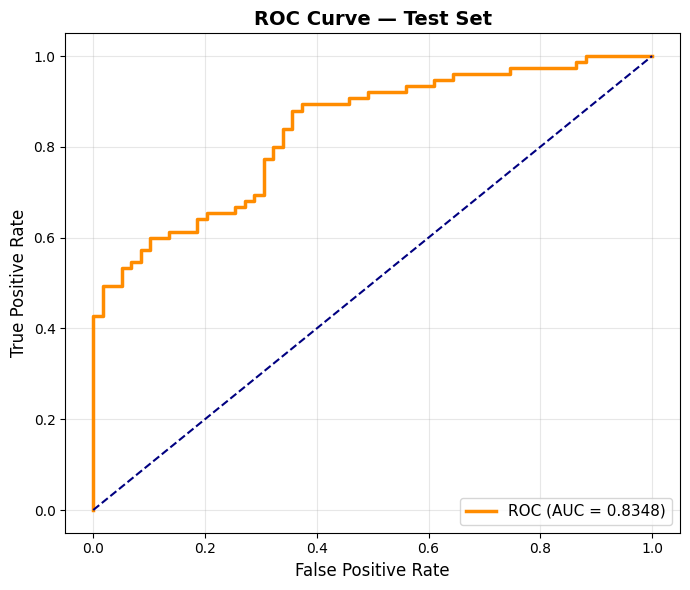

In [16]:
# --- CELL 15: ROC Curve ---
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Test Set', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'roc_curve.png'), dpi=120, bbox_inches='tight')
plt.show()

In [17]:
# --- CELL 16: Feature & Metadata Extraction ---
print('\nExtracting and saving image features split-wise...')
model.eval()

for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    split_loader = DataLoader(
        MIMICDataset(split_df, tfms['val']),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    )

    feats = []
    labs  = []

    with torch.no_grad():
        for imgs, labels in split_loader:
            feat = model.get_features(imgs.to(DEVICE)).cpu()
            feats.append(feat)
            labs.extend(labels.tolist())

    img_features = torch.cat(feats)
    feat_path = os.path.join(SAVE_DIR, f'image_features_{split_name}.pt')
    torch.save({'features': img_features, 'labels': torch.tensor(labs)}, feat_path)
    print(f'{split_name:6s} | Features shape: {img_features.shape} | Saved to {feat_path}')

    meta_df          = split_df[['subject_id', 'study_id', 'label', 'label_name']].copy()
    meta_df['split'] = split_name
    meta_path        = feat_path.replace('.pt', '_meta.csv')
    meta_df.to_csv(meta_path, index=False)
print('\nExtraction complete.')


Extracting and saving image features split-wise...
train  | Features shape: torch.Size([590, 1024]) | Saved to C:\2026\PneumoFusionNet\mimic\1000_dataset\outputs\Phase_1.1_PA_balanced_scaled\image_features_train.pt
val    | Features shape: torch.Size([130, 1024]) | Saved to C:\2026\PneumoFusionNet\mimic\1000_dataset\outputs\Phase_1.1_PA_balanced_scaled\image_features_val.pt
test   | Features shape: torch.Size([134, 1024]) | Saved to C:\2026\PneumoFusionNet\mimic\1000_dataset\outputs\Phase_1.1_PA_balanced_scaled\image_features_test.pt

Extraction complete.
